# Text2FaceGAN — Reproduction & Extensions
**Projet tuteuré Master MLSD — Université Paris Cité**

Ce notebook reproduit les résultats du papier *"Text2FaceGAN: Face Generation from Fine Grained Textual Descriptions"* (Nasir et al., 2019) en PyTorch, puis propose des évaluations complémentaires.

**Plan :**
1. Installation & imports
2. Téléchargement des données (CelebA + captions)
3. Génération des embeddings texte (Sentence-BERT en remplacement de Skip-Thought)
4. Architecture GAN (reproduction fidèle du papier)
5. Entraînement (200 epochs)
6. Évaluation : Inception Score
7. **Extension 1** : Évaluation FID (meilleure métrique que IS)
8. **Extension 2** : Ablation du label-swapping
9. **Extension 3** : Visualisation et analyse qualitative
10. Conclusion & analyse critique

## 1. Installation & Imports

In [1]:
# ── On utilise le PyTorch natif de Kaggle (CUDA 12.8) ─────────────────────────
# PAS de réinstallation de torch, on garde celui du système
!pip install -q sentence-transformers pytorch-fid Pillow tqdm

import torch
print(f'PyTorch : {torch.__version__}')
print(f'CUDA disponible : {torch.cuda.is_available()}')
print(f'GPU : {torch.cuda.get_device_name(0)}')

PyTorch : 2.10.0+cu128
CUDA disponible : True
GPU : Tesla T4


In [2]:
import os
import random
import pickle
import json
import time
import math
import shutil
from pathlib import Path
from collections import defaultdict

import numpy as np
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
from PIL import Image
from tqdm.auto import tqdm

import torch
import torch.nn as nn
import torch.nn.functional as F
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader
import torchvision.transforms as transforms
import torchvision.utils as vutils
from torchvision.models import inception_v3

from sentence_transformers import SentenceTransformer

# ── Config globale ─────────────────────────────────────────────────────────────
SEED = 35
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)

DEVICE = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f'Device : {DEVICE}')
if torch.cuda.is_available():
    print(f'GPU : {torch.cuda.get_device_name(0)}')
    torch.cuda.manual_seed(SEED)

Device : cuda
GPU : Tesla T4


## 2. Téléchargement des données

In [3]:
# ── Hyperparamètres (fidèles au papier) ───────────────────────────────────────
CFG = {
    # Architecture
    'z_dim'              : 100,       # bruit d'entrée du générateur
    'text_embed_dim'     : 384,       # dim sortie Sentence-BERT (all-MiniLM-L6-v2)
    'text_reduced_dim'   : 256,       # dim après projection (= t_dim dans le papier)
    'gf_dim'             : 64,        # filtres de base du générateur
    'df_dim'             : 64,        # filtres de base du discriminateur
    'image_size'         : 64,
    'nc'                 : 3,         # canaux RGB

    # Entraînement
    'batch_size'         : 64,
    'epochs'             : 200,
    'lr_g'               : 0.0002,    # identique au papier
    'lr_d'               : 0.0001,    # identique au papier
    'beta1'              : 0.5,
    'beta2'              : 0.5,
    'n_train'            : 7500,      # identique au papier
    'n_test'             : 2500,      # identique au papier
    'label_swap_every'   : 3,         # swap réel/faux tous les 3 batches (contribution du papier)

    # Chemins
    'data_dir'           : '/kaggle/working/data',
    'celeba_dir'         : '/kaggle/working/data/celeba',
    'caps_file'          : '/kaggle/working/data/caps.txt',
    'embed_file'         : '/kaggle/working/data/embeddings.pkl',
    'checkpoint_dir'     : '/kaggle/working/checkpoints',
    'samples_dir'        : '/kaggle/working/samples',
    'real_samples_dir'   : '/kaggle/working/real_samples',
}

# Création des dossiers
for d in [CFG['data_dir'], CFG['checkpoint_dir'], CFG['samples_dir'], CFG['real_samples_dir']]:
    os.makedirs(d, exist_ok=True)

print('Dossiers créés ✓')

Dossiers créés ✓


In [4]:
# ── Téléchargement de CelebA via Kaggle Datasets ──────────────────────────────
# CelebA est disponible nativement sur Kaggle.
# Dans un notebook Kaggle, ajouter le dataset 'jessicali9530/celeba-dataset'
# via l'interface (Add Data → Search 'celeba') puis adapter le chemin.

# Si le dataset est monté via Kaggle :
CELEBA_KAGGLE = '/kaggle/input/datasets/jessicali9530/celeba-dataset/img_align_celeba/img_align_celeba'

# Vérification
if os.path.exists(CELEBA_KAGGLE):
    imgs = os.listdir(CELEBA_KAGGLE)
    print(f'CelebA trouvé : {len(imgs)} images')
    CFG['img_dir'] = CELEBA_KAGGLE
else:
    # Fallback : téléchargement via gdown (lien Google Drive officiel)
    print('CelebA non trouvé en /kaggle/input — tentative de téléchargement...')
    os.makedirs(CFG['celeba_dir'], exist_ok=True)
    # Images 64x64 alignées (partition officielle)
    !gdown --id 0B7EVK8r0v71pZjFTYXZWM3FlRnM -O /kaggle/working/data/img_align_celeba.zip
    !unzip -q /kaggle/working/data/img_align_celeba.zip -d /kaggle/working/data/celeba/
    CFG['img_dir'] = '/kaggle/working/data/celeba/img_align_celeba'
    print(f"CelebA téléchargé : {len(os.listdir(CFG['img_dir']))} images")

CelebA trouvé : 202599 images


In [5]:
# ── Téléchargement des captions générées par les auteurs ─────────────────────
# caps.txt est dans le repo GitHub officiel
CAPS_KAGGLE = '/kaggle/input/text2facegan-caps/caps.txt'  # si uploadé comme dataset Kaggle

if os.path.exists(CAPS_KAGGLE):
    shutil.copy(CAPS_KAGGLE, CFG['caps_file'])
    print('caps.txt copié depuis dataset Kaggle ✓')
elif not os.path.exists(CFG['caps_file']):
    print('Téléchargement de caps.txt depuis GitHub...')
    !wget -q https://raw.githubusercontent.com/midas-research/text2facegan/master/data/caps.txt -O {CFG['caps_file']}

# Lecture et vérification
captions_raw = {}
with open(CFG['caps_file'], 'r') as f:
    for line in f:
        line = line.strip()
        if not line:
            continue
        parts = line.split('\t', 1)
        if len(parts) == 2:
            img_name, caps_str = parts
            # Toutes les captions d'une image sont jointes (comme dans le papier)
            caption = caps_str.replace('|', ' ').strip()
            captions_raw[img_name] = caption

print(f'Captions chargées : {len(captions_raw)} entrées')
# Exemple
sample_key = list(captions_raw.keys())[0]
print(f'\nExemple — {sample_key}:')
print(captions_raw[sample_key])

Téléchargement de caps.txt depuis GitHub...
Captions chargées : 192050 entrées

Exemple — 000001.jpg:
The woman has high cheekbones. She has straight hair which is brown in colour. She has pointy nose with arched eyebrows and a slightly open mouth. The smiling, young attractive woman has heavy makeup. She's wearing earrings and lipstick.


## 3. Encodage des captions

Le papier utilise **Skip-Thought vectors** (4800 dim) dont les poids (~10 Go) sont difficiles à télécharger. Nous utilisons **Sentence-BERT** (`all-MiniLM-L6-v2`, 384 dim) qui :
- Est plus léger et facile à utiliser
- Produit de meilleurs embeddings sémantiques (BERT vs GRU de 2015)
- Est une des extensions explicitement suggérées dans la section VI du papier

In [6]:
# ── Génération des embeddings Sentence-BERT ───────────────────────────────────
if os.path.exists(CFG['embed_file']):
    print('Embeddings déjà calculés, chargement...')
    with open(CFG['embed_file'], 'rb') as f:
        embeddings = pickle.load(f)
else:
    print('Calcul des embeddings Sentence-BERT (all-MiniLM-L6-v2)...')
    # Force CPU pour éviter le conflit CUDA avec sentence-transformers
    sbert = SentenceTransformer('all-MiniLM-L6-v2', device='cpu')
    
    img_names = list(captions_raw.keys())
    captions_list = [captions_raw[k] for k in img_names]

    batch_size_enc = 256  # plus petit batch sur CPU
    all_vecs = []
    for i in tqdm(range(0, len(captions_list), batch_size_enc), desc='Encoding'):
        batch = captions_list[i:i+batch_size_enc]
        vecs = sbert.encode(batch, convert_to_numpy=True, show_progress_bar=False)
        all_vecs.append(vecs)

    all_vecs = np.concatenate(all_vecs, axis=0)
    embeddings = {img_names[i]: all_vecs[i] for i in range(len(img_names))}

    with open(CFG['embed_file'], 'wb') as f:
        pickle.dump(embeddings, f)
    print(f'Embeddings sauvegardés : {len(embeddings)} vecteurs de dim {all_vecs.shape[1]}')

print(f'\nDim embedding : {next(iter(embeddings.values())).shape}')

Calcul des embeddings Sentence-BERT (all-MiniLM-L6-v2)...


modules.json:   0%|          | 0.00/349 [00:00<?, ?B/s]

config_sentence_transformers.json:   0%|          | 0.00/116 [00:00<?, ?B/s]

README.md: 0.00B [00:00, ?B/s]

sentence_bert_config.json:   0%|          | 0.00/53.0 [00:00<?, ?B/s]

...

tokenizer.json: 0.00B [00:00, ?B/s]

special_tokens_map.json:   0%|          | 0.00/112 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/190 [00:00<?, ?B/s]

Encoding:   0%|          | 0/751 [00:00<?, ?it/s]

Embeddings sauvegardés : 192050 vecteurs de dim 384

Dim embedding : (384,)


## 4. Dataset & DataLoader

In [7]:
class FaceTextDataset(Dataset):
    """
    Dataset CelebA + captions, fidèle au protocole du papier :
    - 7500 images pour train, 2500 pour test
    - 10 000 images sélectionnées aléatoirement dans CelebA
    - Wrong image : image aléatoire différente (pour GAN-CLS)
    """
    def __init__(self, img_dir, embeddings, image_size=64, split='train',
                 n_train=7500, n_test=2500, seed=42):
        self.img_dir = img_dir
        self.embeddings = embeddings
        self.image_size = image_size

        # Intersection : images qui ont à la fois une image et un embedding
        available_imgs = set(os.listdir(img_dir))
        available_embs = set(embeddings.keys())
        all_valid = sorted(list(available_imgs & available_embs))

        # Sélection de 10 000 images (protocole du papier)
        rng = random.Random(seed)
        selected = rng.sample(all_valid, min(n_train + n_test, len(all_valid)))

        if split == 'train':
            self.img_list = selected[:n_train]
        else:
            self.img_list = selected[n_train:n_train + n_test]

        self.transform = transforms.Compose([
            transforms.Resize(image_size),
            transforms.CenterCrop(image_size),
            transforms.RandomHorizontalFlip(),  # data augmentation comme dans le papier
            transforms.ToTensor(),
            transforms.Normalize([0.5, 0.5, 0.5], [0.5, 0.5, 0.5]),  # → [-1, 1]
        ])
        print(f'[{split}] {len(self.img_list)} images chargées')

    def __len__(self):
        return len(self.img_list)

    def __getitem__(self, idx):
        img_name = self.img_list[idx]
        img_path = os.path.join(self.img_dir, img_name)

        img = Image.open(img_path).convert('RGB')
        real_img = self.transform(img)

        # Wrong image : image aléatoire avec caption différente (GAN-CLS)
        wrong_idx = random.randint(0, len(self.img_list) - 1)
        while wrong_idx == idx:
            wrong_idx = random.randint(0, len(self.img_list) - 1)
        wrong_name = self.img_list[wrong_idx]
        wrong_img = Image.open(os.path.join(self.img_dir, wrong_name)).convert('RGB')
        wrong_img = self.transform(wrong_img)

        caption_vec = torch.tensor(self.embeddings[img_name], dtype=torch.float32)
        return real_img, wrong_img, caption_vec, img_name


train_dataset = FaceTextDataset(
    CFG['img_dir'], embeddings,
    image_size=CFG['image_size'], split='train',
    n_train=CFG['n_train'], n_test=CFG['n_test']
)
test_dataset = FaceTextDataset(
    CFG['img_dir'], embeddings,
    image_size=CFG['image_size'], split='test',
    n_train=CFG['n_train'], n_test=CFG['n_test']
)

train_loader = DataLoader(
    train_dataset, batch_size=CFG['batch_size'],
    shuffle=True, num_workers=2, drop_last=True, pin_memory=True
)
test_loader = DataLoader(
    test_dataset, batch_size=CFG['batch_size'],
    shuffle=False, num_workers=2, drop_last=True, pin_memory=True
)

print(f'\nBatches train : {len(train_loader)} | Batches test : {len(test_loader)}')

[train] 7500 images chargées
[test] 2500 images chargées

Batches train : 117 | Batches test : 39


## 4. Architecture du GAN

Reproduction fidèle du DCGAN conditionné sur les captions (GAN-CLS) décrit dans le papier :
- **Générateur** : projection + 4 couches déconvolutionnelles → image 64×64
- **Discriminateur** : 4 couches convolutionnelles + injection du texte → score réel/faux
- **GAN-CLS** : le discriminateur reçoit 3 paires : (real, right_cap), (real, wrong_cap), (fake, right_cap)

In [8]:
def weights_init(m):
    """Initialisation des poids (convention DCGAN)"""
    classname = m.__class__.__name__
    if 'Conv' in classname:
        nn.init.normal_(m.weight.data, 0.0, 0.02)
    elif 'BatchNorm' in classname:
        nn.init.normal_(m.weight.data, 1.0, 0.02)
        nn.init.constant_(m.bias.data, 0)


class Generator(nn.Module):
    """
    Générateur Text2FaceGAN.
    Entrée : bruit z (z_dim) + embedding texte (text_embed_dim)
    Sortie : image RGB 64×64 dans [-1, 1]

    Architecture fidèle au papier :
    - Réduction du texte : 384 → 256 (fully connected + LeakyReLU)
    - Concaténation z + texte_réduit = 356 dim
    - Projection vers 4×4×512
    - 4 couches déconvolutionnelles : 4→8→16→32→64 px, 512→256→128→64→3 ch
    """
    def __init__(self, z_dim, text_embed_dim, text_reduced_dim, gf_dim):
        super().__init__()
        self.z_dim = z_dim
        self.gf_dim = gf_dim

        # Réduction du texte (FC + LeakyReLU)
        self.text_proj = nn.Sequential(
            nn.Linear(text_embed_dim, text_reduced_dim),
            nn.LeakyReLU(0.2, inplace=True)
        )

        # Projection initiale : (z_dim + text_reduced_dim) → 4×4×(gf_dim*8)
        concat_dim = z_dim + text_reduced_dim  # 100 + 256 = 356
        self.proj = nn.Linear(concat_dim, gf_dim * 8 * 4 * 4)
        self.bn0 = nn.BatchNorm2d(gf_dim * 8)

        # Couches déconvolutionnelles
        self.deconv1 = nn.ConvTranspose2d(gf_dim*8, gf_dim*4, 4, 2, 1, bias=False)  # 4→8
        self.bn1     = nn.BatchNorm2d(gf_dim * 4)
        self.deconv2 = nn.ConvTranspose2d(gf_dim*4, gf_dim*2, 4, 2, 1, bias=False)  # 8→16
        self.bn2     = nn.BatchNorm2d(gf_dim * 2)
        self.deconv3 = nn.ConvTranspose2d(gf_dim*2, gf_dim*1, 4, 2, 1, bias=False)  # 16→32
        self.bn3     = nn.BatchNorm2d(gf_dim * 1)
        self.deconv4 = nn.ConvTranspose2d(gf_dim*1, 3,        4, 2, 1, bias=False)  # 32→64

    def forward(self, z, text_emb):
        t = self.text_proj(text_emb)          # (B, 256)
        inp = torch.cat([z, t], dim=1)        # (B, 356)
        h = self.proj(inp)                    # (B, gf*8*4*4)
        h = h.view(-1, self.gf_dim*8, 4, 4)  # (B, 512, 4, 4)
        h = F.relu(self.bn0(h))
        h = F.relu(self.bn1(self.deconv1(h)))  # (B, 256, 8, 8)
        h = F.relu(self.bn2(self.deconv2(h)))  # (B, 128, 16, 16)
        h = F.relu(self.bn3(self.deconv3(h)))  # (B, 64, 32, 32)
        h = torch.tanh(self.deconv4(h))        # (B, 3, 64, 64) dans [-1,1]
        return h


class Discriminator(nn.Module):
    """
    Discriminateur Text2FaceGAN (GAN-CLS).
    Entrée : image 64×64 + embedding texte
    Sortie : probabilité [0, 1] que la paire (image, texte) soit réelle

    Architecture fidèle au papier :
    - 4 couches conv (stride 2) : 64→32→16→8→4 px, 3→64→128→256→512 ch
    - Injection du texte réduit (256→4×4×256) concaténé au feature map 4×4×512
    - Couche conv finale sur 4×4×768 → 4×4×512 → FC → sigmoid
    """
    def __init__(self, text_embed_dim, text_reduced_dim, df_dim):
        super().__init__()

        self.conv0 = nn.Conv2d(3,        df_dim*1, 4, 2, 1, bias=False)  # 64→32
        self.conv1 = nn.Conv2d(df_dim*1, df_dim*2, 4, 2, 1, bias=False)  # 32→16
        self.bn1   = nn.BatchNorm2d(df_dim * 2)
        self.conv2 = nn.Conv2d(df_dim*2, df_dim*4, 4, 2, 1, bias=False)  # 16→8
        self.bn2   = nn.BatchNorm2d(df_dim * 4)
        self.conv3 = nn.Conv2d(df_dim*4, df_dim*8, 4, 2, 1, bias=False)  # 8→4
        self.bn3   = nn.BatchNorm2d(df_dim * 8)

        # Projection texte → 4×4×text_reduced_dim
        self.text_proj = nn.Sequential(
            nn.Linear(text_embed_dim, text_reduced_dim),
            nn.LeakyReLU(0.2, inplace=True)
        )

        # Couche finale après concaténation texte
        self.conv4 = nn.Conv2d(df_dim*8 + text_reduced_dim, df_dim*8, 1, 1, 0, bias=False)
        self.bn4   = nn.BatchNorm2d(df_dim * 8)
        self.fc    = nn.Linear(df_dim * 8 * 4 * 4, 1)

    def forward(self, img, text_emb):
        h = F.leaky_relu(self.conv0(img), 0.2)           # (B, 64, 32, 32)
        h = F.leaky_relu(self.bn1(self.conv1(h)), 0.2)   # (B, 128, 16, 16)
        h = F.leaky_relu(self.bn2(self.conv2(h)), 0.2)   # (B, 256, 8, 8)
        h = F.leaky_relu(self.bn3(self.conv3(h)), 0.2)   # (B, 512, 4, 4)

        # Injection du texte
        t = self.text_proj(text_emb)             # (B, 256)
        t = t.unsqueeze(-1).unsqueeze(-1)        # (B, 256, 1, 1)
        t = t.expand(-1, -1, 4, 4)              # (B, 256, 4, 4)
        h = torch.cat([h, t], dim=1)             # (B, 768, 4, 4)

        h = F.leaky_relu(self.bn4(self.conv4(h)), 0.2)   # (B, 512, 4, 4)
        h = h.view(h.size(0), -1)                         # (B, 8192)
        out = self.fc(h)                                   # (B, 1)
        return torch.sigmoid(out), out  # (prob, logit)


# Instanciation
G = Generator(
    z_dim=CFG['z_dim'],
    text_embed_dim=CFG['text_embed_dim'],
    text_reduced_dim=CFG['text_reduced_dim'],
    gf_dim=CFG['gf_dim']
).to(DEVICE)

D = Discriminator(
    text_embed_dim=CFG['text_embed_dim'],
    text_reduced_dim=CFG['text_reduced_dim'],
    df_dim=CFG['df_dim']
).to(DEVICE)

G.apply(weights_init)
D.apply(weights_init)

# Affichage du nombre de paramètres
n_G = sum(p.numel() for p in G.parameters() if p.requires_grad)
n_D = sum(p.numel() for p in D.parameters() if p.requires_grad)
print(f'Paramètres G : {n_G:,} | Paramètres D : {n_D:,}')

# Optimiseurs (identiques au papier)
opt_G = optim.Adam(G.parameters(), lr=CFG['lr_g'], betas=(CFG['beta1'], CFG['beta2']))
opt_D = optim.Adam(D.parameters(), lr=CFG['lr_d'], betas=(CFG['beta1'], CFG['beta2']))

criterion = nn.BCEWithLogitsLoss()

Paramètres G : 5,780,608 | Paramètres D : 3,258,369


## 5. Entraînement

Implémentation fidèle du papier :
- Mise à jour du **générateur 2 fois** par batch (pour éviter que D converge trop vite)
- **Label swapping** tous les 3 batches : les images réelles et fausses sont échangées pour le discriminateur
- Perte GAN-CLS : D reçoit (réel+bonne_cap), (réel+mauvaise_cap), (faux+bonne_cap)

In [9]:
def save_samples(G, epoch, batch_no, fixed_z, fixed_captions, save_dir, n=16):
    """Sauvegarde une grille d'images générées."""
    G.eval()
    with torch.no_grad():
        fake = G(fixed_z[:n], fixed_captions[:n])
    G.train()
    # De [-1,1] vers [0,1]
    fake = (fake + 1) / 2
    grid = vutils.make_grid(fake, nrow=4, normalize=False, padding=2)
    path = os.path.join(save_dir, f'epoch_{epoch:03d}_batch_{batch_no:04d}.png')
    vutils.save_image(grid, path)
    return path


def train_one_epoch(G, D, opt_G, opt_D, loader, epoch, history,
                    label_swap_every=3, swap=True):
    """
    Entraînement d'une epoch.
    swap=True  : label swapping activé (version papier)
    swap=False : sans label swapping (ablation)
    """
    G.train(); D.train()
    epoch_d_loss = 0
    epoch_g_loss = 0
    n_batches = 0

    for batch_no, (real_imgs, wrong_imgs, captions, _) in enumerate(loader):
        B = real_imgs.size(0)
        real_imgs = real_imgs.to(DEVICE)
        wrong_imgs = wrong_imgs.to(DEVICE)
        captions   = captions.to(DEVICE)

        real_labels = torch.ones(B, 1, device=DEVICE)
        fake_labels = torch.zeros(B, 1, device=DEVICE)

        # ── Génération ──────────────────────────────────────────────────────
        z = torch.randn(B, CFG['z_dim'], device=DEVICE)
        fake_imgs = G(z, captions)

        # ── Mise à jour du générateur (×2 par batch, comme dans le papier) ──
        for _ in range(2):
            opt_G.zero_grad()
            z = torch.randn(B, CFG['z_dim'], device=DEVICE)
            fake_imgs = G(z, captions)
            _, fake_logits = D(fake_imgs, captions)
            g_loss = criterion(fake_logits, real_labels)  # G veut que D croit au faux
            g_loss.backward()
            opt_G.step()

        # ── Mise à jour du discriminateur ────────────────────────────────────
        opt_D.zero_grad()

        # Label swapping : tous les `label_swap_every` batches, on donne les
        # fausses images comme "réelles" au discriminateur → ralentit D
        # (contribution principale du papier, section IV.B)
        if swap and (batch_no % label_swap_every == 0):
            d_input_real = fake_imgs.detach()   # ← swap
        else:
            d_input_real = real_imgs

        # 3 termes de la perte GAN-CLS (Eq. 4 du papier)
        _, d_real_logits  = D(d_input_real, captions)   # paire réelle
        _, d_wrong_logits = D(wrong_imgs, captions)      # image réelle, mauvaise caption
        _, d_fake_logits  = D(fake_imgs.detach(), captions)  # image générée

        d_loss1 = criterion(d_real_logits,  real_labels)  # réel → 1
        d_loss2 = criterion(d_wrong_logits, fake_labels)   # mauvaise paire → 0
        d_loss3 = criterion(d_fake_logits,  fake_labels)   # faux → 0
        d_loss  = d_loss1 + d_loss2 + d_loss3

        d_loss.backward()
        opt_D.step()

        epoch_d_loss += d_loss.item()
        epoch_g_loss += g_loss.item()
        n_batches += 1

    history['d_loss'].append(epoch_d_loss / n_batches)
    history['g_loss'].append(epoch_g_loss / n_batches)
    return epoch_d_loss / n_batches, epoch_g_loss / n_batches

In [10]:
# ── Données fixes pour visualiser l'évolution ─────────────────────────────────
real_sample, _, caption_sample, names_sample = next(iter(test_loader))
fixed_z       = torch.randn(CFG['batch_size'], CFG['z_dim'], device=DEVICE)
fixed_captions = caption_sample.to(DEVICE)

# ── Historique des pertes ─────────────────────────────────────────────────────
history = {'d_loss': [], 'g_loss': []}

print('Démarrage de l\'entraînement...')
print(f'Epochs : {CFG["epochs"]} | Batches/epoch : {len(train_loader)} | Device : {DEVICE}')

start_time = time.time()
for epoch in range(1, CFG['epochs'] + 1):
    d_loss, g_loss = train_one_epoch(
        G, D, opt_G, opt_D, train_loader, epoch, history,
        label_swap_every=CFG['label_swap_every'], swap=True
    )

    elapsed = (time.time() - start_time) / 60
    eta = elapsed / epoch * (CFG['epochs'] - epoch)
    print(f'Epoch [{epoch:3d}/{CFG["epochs"]}] '
          f'D_loss: {d_loss:.4f} | G_loss: {g_loss:.4f} | '
          f'Elapsed: {elapsed:.1f}min | ETA: {eta:.1f}min')

    # Sauvegarde des samples toutes les 10 epochs
    if epoch % 10 == 0 or epoch == 1:
        path = save_samples(G, epoch, 0, fixed_z, fixed_captions, CFG['samples_dir'])

    # Sauvegarde du checkpoint toutes les 50 epochs
    if epoch % 50 == 0:
        torch.save({
            'epoch': epoch,
            'G_state': G.state_dict(),
            'D_state': D.state_dict(),
            'opt_G': opt_G.state_dict(),
            'opt_D': opt_D.state_dict(),
            'history': history,
        }, os.path.join(CFG['checkpoint_dir'], f'ckpt_epoch_{epoch}.pt'))
        print(f'  → Checkpoint sauvegardé (epoch {epoch})')

print(f'\nEntraînement terminé en {(time.time()-start_time)/60:.1f} minutes')

Démarrage de l'entraînement...
Epochs : 200 | Batches/epoch : 117 | Device : cuda
Epoch [  1/200] D_loss: 3.0325 | G_loss: 0.3276 | Elapsed: 0.7min | ETA: 133.9min
Epoch [  2/200] D_loss: 2.4463 | G_loss: 0.7286 | Elapsed: 0.9min | ETA: 91.9min
Epoch [  3/200] D_loss: 2.0985 | G_loss: 1.0420 | Elapsed: 1.2min | ETA: 78.3min
Epoch [  4/200] D_loss: 2.0234 | G_loss: 1.0179 | Elapsed: 1.5min | ETA: 71.2min
Epoch [  5/200] D_loss: 1.9824 | G_loss: 0.9954 | Elapsed: 1.7min | ETA: 67.1min
Epoch [  6/200] D_loss: 1.9558 | G_loss: 0.9992 | Elapsed: 2.0min | ETA: 64.4min
Epoch [  7/200] D_loss: 1.9470 | G_loss: 1.0027 | Elapsed: 2.3min | ETA: 62.6min
Epoch [  8/200] D_loss: 1.9336 | G_loss: 1.0013 | Elapsed: 2.6min | ETA: 61.3min
Epoch [  9/200] D_loss: 1.9234 | G_loss: 0.9962 | Elapsed: 2.8min | ETA: 60.1min
Epoch [ 10/200] D_loss: 1.9140 | G_loss: 0.9789 | Elapsed: 3.1min | ETA: 59.0min
Epoch [ 11/200] D_loss: 1.8763 | G_loss: 0.9386 | Elapsed: 3.4min | ETA: 58.2min
Epoch [ 12/200] D_loss: 1.

## 6. Évaluation : Inception Score (IS)

Calcul de l'Inception Score tel que décrit dans le papier (section V). Le papier obtient **1.4 ± 0.7** sur 5 itérations.

In [11]:
def compute_inception_score(G, loader, n_samples=5000, n_splits=5, device=DEVICE):
    """
    Calcule l'Inception Score (IS).
    IS = exp(E[KL(p(y|x) || p(y))]) — Eq. 8 du papier
    """
    # Charger InceptionV3 pré-entraîné sur ImageNet
    inception = inception_v3(pretrained=True, transform_input=False).to(device)
    inception.eval()

    # Patch pour obtenir les logits (avant softmax)
    inception.fc = nn.Identity()
    # On va utiliser le vrai InceptionV3 avec la tête complète
    inception_full = inception_v3(pretrained=True, transform_input=False).to(device)
    inception_full.eval()

    resize_transform = transforms.Compose([
        transforms.Resize(299),
        transforms.CenterCrop(299),
    ])

    all_preds = []
    G.eval()

    with torch.no_grad():
        n_generated = 0
        for real_imgs, _, captions, _ in loader:
            if n_generated >= n_samples:
                break
            captions = captions.to(device)
            B = captions.size(0)
            z = torch.randn(B, CFG['z_dim'], device=device)
            fake = G(z, captions)            # [-1, 1]
            fake = (fake + 1) / 2            # [0, 1]
            fake_resized = resize_transform(fake)

            preds = inception_full(fake_resized)
            preds = F.softmax(preds, dim=1).cpu().numpy()
            all_preds.append(preds)
            n_generated += B

    G.train()
    all_preds = np.concatenate(all_preds, axis=0)[:n_samples]

    # Calcul IS sur n_splits partitions
    scores = []
    split_size = all_preds.shape[0] // n_splits
    for i in range(n_splits):
        part = all_preds[i*split_size:(i+1)*split_size]
        p_yx = part                       # p(y|x) : chaque image
        p_y  = part.mean(axis=0)          # p(y) marginale
        kl = p_yx * (np.log(p_yx + 1e-10) - np.log(p_y + 1e-10))
        kl = kl.sum(axis=1).mean()
        scores.append(np.exp(kl))

    is_mean = np.mean(scores)
    is_std  = np.std(scores)
    return is_mean, is_std


print('Calcul de l\'Inception Score...')
is_mean, is_std = compute_inception_score(G, test_loader, n_samples=2500, n_splits=5)
print(f'\nInception Score : {is_mean:.2f} ± {is_std:.2f}')
print(f'(Papier : 1.4 ± 0.7)')

Calcul de l'Inception Score...
Downloading: "https://download.pytorch.org/models/inception_v3_google-0cc3c7bd.pth" to /root/.cache/torch/hub/checkpoints/inception_v3_google-0cc3c7bd.pth


/usr/local/lib/python3.12/dist-packages/torchvision/models/_utils.py:208: UserWarning: The parameter 'pretrained' is deprecated since 0.13 and may be removed in the future, please use 'weights' instead.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/torchvision/models/_utils.py:223: UserWarning: Arguments other than a weight enum or `None` for 'weights' are deprecated since 0.13 and may be removed in the future. The current behavior is equivalent to passing `weights=Inception_V3_Weights.IMAGENET1K_V1`. You can also use `weights=Inception_V3_Weights.DEFAULT` to get the most up-to-date weights.
  warnings.warn(msg)
100%|██████████| 104M/104M [00:00<00:00, 203MB/s] 



Inception Score : 1.65 ± 0.02
(Papier : 1.4 ± 0.7)


## 7. Extension 1 — FID (Fréchet Inception Distance)

Le papier lui-même admet que l'IS est une mauvaise métrique pour les visages (section V). Nous calculons le **FID**, une métrique bien meilleure pour évaluer la qualité et la diversité des images générées.

FID mesure la distance entre la distribution des images réelles et générées dans l'espace des features InceptionV3. Un **FID plus bas = meilleur**.

In [12]:
from scipy import linalg

def get_inception_features(imgs_tensor, inception_model, device):
    """Extrait les features du pool avant la couche FC d'InceptionV3."""
    resize_fn = transforms.Resize(299)
    imgs_resized = resize_fn(imgs_tensor)
    with torch.no_grad():
        feat = inception_model(imgs_resized)
    return feat.cpu().numpy()


def compute_fid(real_features, fake_features):
    """
    Calcule le FID entre deux ensembles de features.
    FID = ||μ_r - μ_f||² + Tr(Σ_r + Σ_f - 2(Σ_r Σ_f)^{1/2})
    """
    mu_r, sigma_r = real_features.mean(0), np.cov(real_features, rowvar=False)
    mu_f, sigma_f = fake_features.mean(0), np.cov(fake_features, rowvar=False)

    diff = mu_r - mu_f
    # Racine carrée matricielle
    covmean, _ = linalg.sqrtm(sigma_r @ sigma_f, disp=False)
    if np.iscomplexobj(covmean):
        covmean = covmean.real

    fid = diff @ diff + np.trace(sigma_r + sigma_f - 2 * covmean)
    return float(fid)


# Modèle InceptionV3 pour features (sans la couche FC)
inception_feat = inception_v3(pretrained=True, transform_input=False)
inception_feat.fc = nn.Identity()   # on prend les features 2048-dim
inception_feat = inception_feat.to(DEVICE).eval()

print('Extraction des features (images réelles)...')
real_feats = []
fake_feats = []
G.eval()

with torch.no_grad():
    for real_imgs, _, captions, _ in tqdm(test_loader, desc='FID features'):
        real_imgs = real_imgs.to(DEVICE)
        captions  = captions.to(DEVICE)
        B = real_imgs.size(0)

        # Features images réelles
        r_feat = get_inception_features((real_imgs + 1)/2, inception_feat, DEVICE)
        real_feats.append(r_feat)

        # Features images générées
        z = torch.randn(B, CFG['z_dim'], device=DEVICE)
        fake = G(z, captions)
        f_feat = get_inception_features((fake + 1)/2, inception_feat, DEVICE)
        fake_feats.append(f_feat)

G.train()

real_feats = np.concatenate(real_feats, axis=0)
fake_feats = np.concatenate(fake_feats, axis=0)

fid_score = compute_fid(real_feats, fake_feats)
print(f'\nFID Score : {fid_score:.2f}')
print('(FID < 100 est généralement considéré comme acceptable pour un DCGAN)')

Extraction des features (images réelles)...


FID features:   0%|          | 0/39 [00:00<?, ?it/s]

/tmp/ipykernel_23/2127244088.py:22: DeprecationWarning: The `disp` argument is deprecated and will be removed in SciPy 1.18.0.
  covmean, _ = linalg.sqrtm(sigma_r @ sigma_f, disp=False)



FID Score : 138.99
(FID < 100 est généralement considéré comme acceptable pour un DCGAN)


## 8. Extension 2 — Ablation du Label Swapping

Le label swapping est la contribution principale du papier. Nous l'ablons pour vérifier son impact réel sur la stabilité de l'entraînement.

In [13]:
print('=== Ablation : entraînement SANS label swapping ===')
print('(Pour comparer avec la version du papier)')

# Nouveau modèle sans swap
G_no_swap = Generator(
    z_dim=CFG['z_dim'],
    text_embed_dim=CFG['text_embed_dim'],
    text_reduced_dim=CFG['text_reduced_dim'],
    gf_dim=CFG['gf_dim']
).to(DEVICE)
D_no_swap = Discriminator(
    text_embed_dim=CFG['text_embed_dim'],
    text_reduced_dim=CFG['text_reduced_dim'],
    df_dim=CFG['df_dim']
).to(DEVICE)
G_no_swap.apply(weights_init)
D_no_swap.apply(weights_init)

opt_G_ns = optim.Adam(G_no_swap.parameters(), lr=CFG['lr_g'], betas=(CFG['beta1'], CFG['beta2']))
opt_D_ns = optim.Adam(D_no_swap.parameters(), lr=CFG['lr_d'], betas=(CFG['beta1'], CFG['beta2']))

# Entraînement sur 50 epochs (ablation rapide)
N_ABLATION_EPOCHS = 50
history_no_swap = {'d_loss': [], 'g_loss': []}

for epoch in range(1, N_ABLATION_EPOCHS + 1):
    d_loss, g_loss = train_one_epoch(
        G_no_swap, D_no_swap, opt_G_ns, opt_D_ns,
        train_loader, epoch, history_no_swap,
        label_swap_every=CFG['label_swap_every'], swap=False   # ← SANS SWAP
    )
    if epoch % 10 == 0:
        print(f'  Epoch [{epoch:3d}/{N_ABLATION_EPOCHS}] '
              f'D_loss: {d_loss:.4f} | G_loss: {g_loss:.4f}')

print('Ablation terminée.')

=== Ablation : entraînement SANS label swapping ===
(Pour comparer avec la version du papier)
  Epoch [ 10/50] D_loss: 1.8740 | G_loss: 1.1915
  Epoch [ 20/50] D_loss: 1.6818 | G_loss: 1.0173
  Epoch [ 30/50] D_loss: 1.3905 | G_loss: 1.0932
  Epoch [ 40/50] D_loss: 1.2287 | G_loss: 1.2313
  Epoch [ 50/50] D_loss: 1.0747 | G_loss: 1.4660
Ablation terminée.


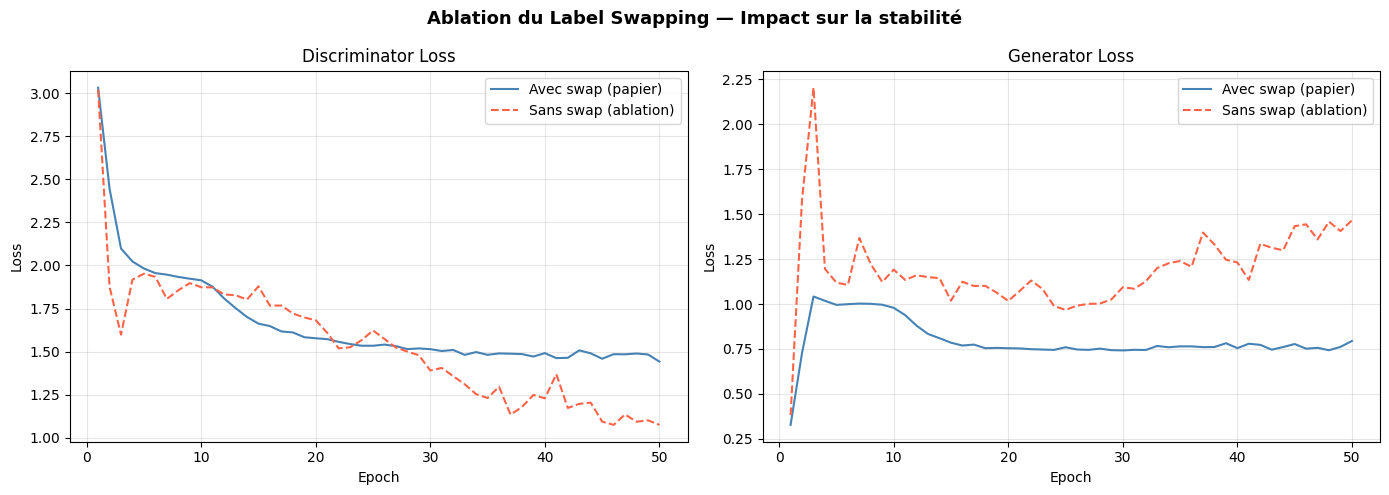

Figure sauvegardée.


In [14]:
# ── Comparaison des courbes de loss ───────────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

n = N_ABLATION_EPOCHS
epochs_full = range(1, len(history['d_loss'][:n]) + 1)
epochs_abl  = range(1, len(history_no_swap['d_loss']) + 1)

axes[0].plot(epochs_full, history['d_loss'][:n],      label='Avec swap (papier)', color='steelblue')
axes[0].plot(epochs_abl,  history_no_swap['d_loss'],  label='Sans swap (ablation)', color='tomato', linestyle='--')
axes[0].set_title('Discriminator Loss')
axes[0].set_xlabel('Epoch')
axes[0].set_ylabel('Loss')
axes[0].legend()
axes[0].grid(alpha=0.3)

axes[1].plot(epochs_full, history['g_loss'][:n],      label='Avec swap (papier)', color='steelblue')
axes[1].plot(epochs_abl,  history_no_swap['g_loss'],  label='Sans swap (ablation)', color='tomato', linestyle='--')
axes[1].set_title('Generator Loss')
axes[1].set_xlabel('Epoch')
axes[1].set_ylabel('Loss')
axes[1].legend()
axes[1].grid(alpha=0.3)

plt.suptitle('Ablation du Label Swapping — Impact sur la stabilité', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig('/kaggle/working/ablation_label_swap.png', dpi=150, bbox_inches='tight')
plt.show()
print('Figure sauvegardée.')

## 9. Extension 3 — Visualisation qualitative & analyse

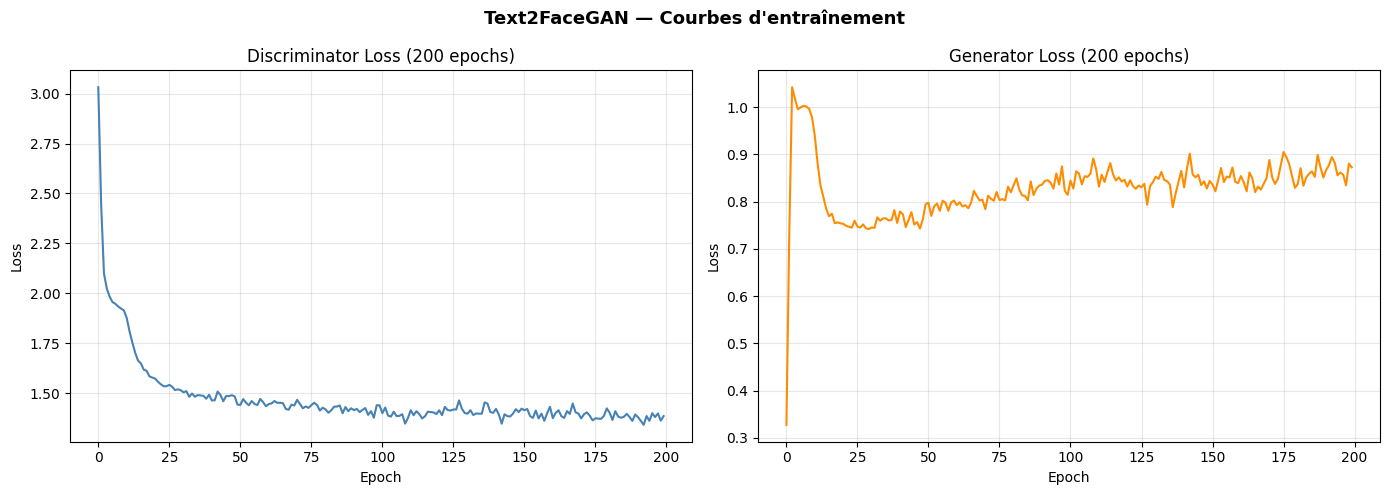

In [15]:
# ── Courbes de loss de l'entraînement principal ────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].plot(history['d_loss'], color='steelblue', linewidth=1.5)
axes[0].set_title('Discriminator Loss (200 epochs)')
axes[0].set_xlabel('Epoch')
axes[0].set_ylabel('Loss')
axes[0].grid(alpha=0.3)

axes[1].plot(history['g_loss'], color='darkorange', linewidth=1.5)
axes[1].set_title('Generator Loss (200 epochs)')
axes[1].set_xlabel('Epoch')
axes[1].set_ylabel('Loss')
axes[1].grid(alpha=0.3)

plt.suptitle('Text2FaceGAN — Courbes d\'entraînement', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig('/kaggle/working/training_curves.png', dpi=150, bbox_inches='tight')
plt.show()

Encodage des captions custom avec Sentence-BERT...


Loading weights:   0%|          | 0/103 [00:00<?, ?it/s]

BertModel LOAD REPORT from: sentence-transformers/all-MiniLM-L6-v2
Key                     | Status     |  | 
------------------------+------------+--+-
embeddings.position_ids | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


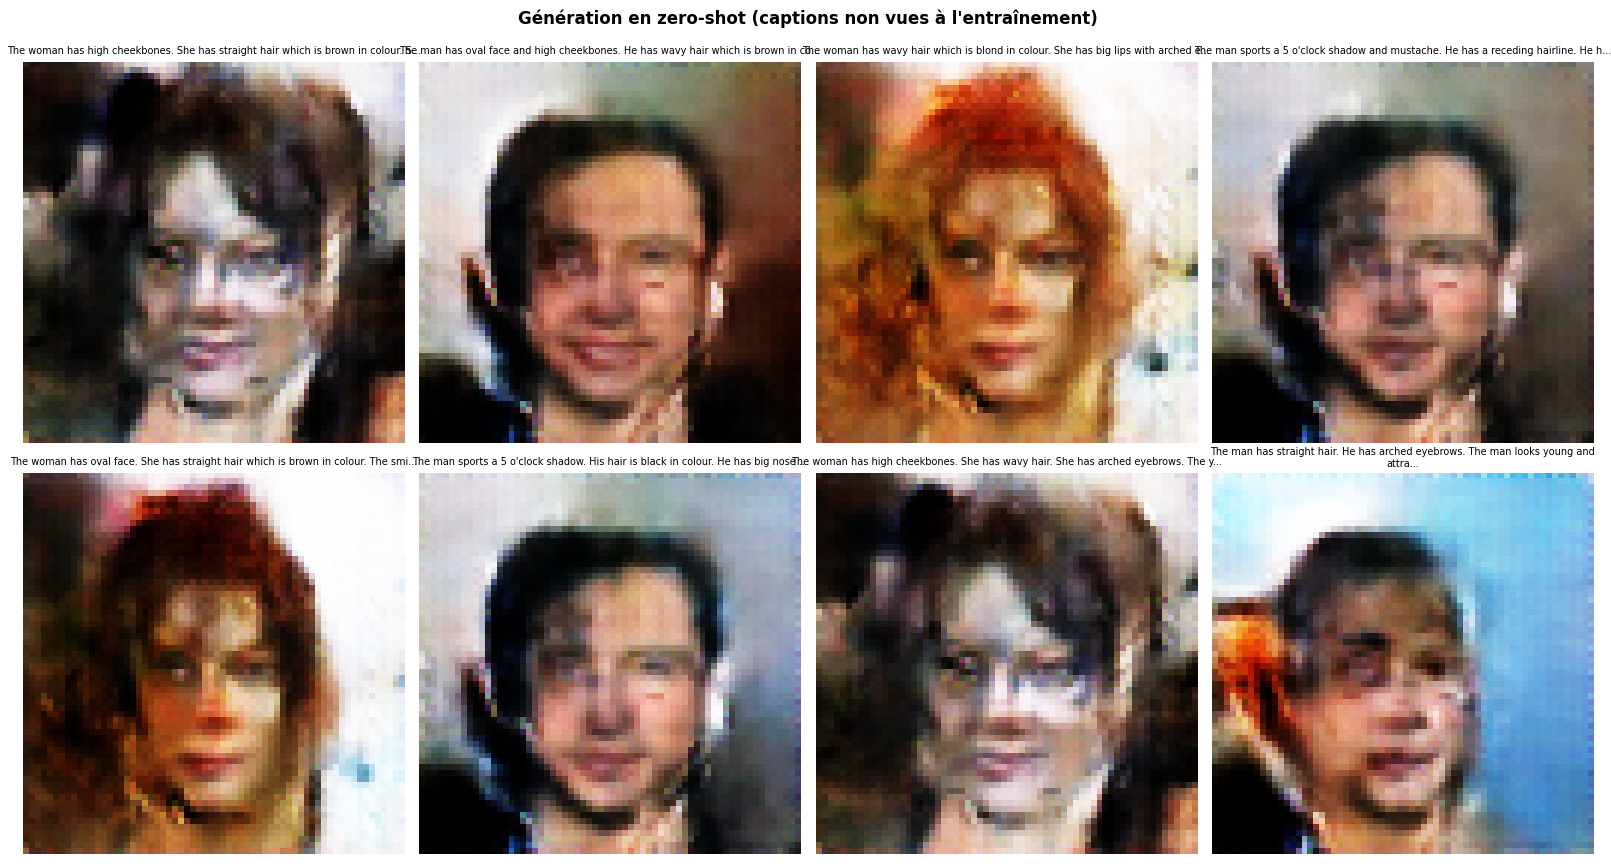

Generator(
  (text_proj): Sequential(
    (0): Linear(in_features=384, out_features=256, bias=True)
    (1): LeakyReLU(negative_slope=0.2, inplace=True)
  )
  (proj): Linear(in_features=356, out_features=8192, bias=True)
  (bn0): BatchNorm2d(512, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  (deconv1): ConvTranspose2d(512, 256, kernel_size=(4, 4), stride=(2, 2), padding=(1, 1), bias=False)
  (bn1): BatchNorm2d(256, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  (deconv2): ConvTranspose2d(256, 128, kernel_size=(4, 4), stride=(2, 2), padding=(1, 1), bias=False)
  (bn2): BatchNorm2d(128, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  (deconv3): ConvTranspose2d(128, 64, kernel_size=(4, 4), stride=(2, 2), padding=(1, 1), bias=False)
  (bn3): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  (deconv4): ConvTranspose2d(64, 3, kernel_size=(4, 4), stride=(2, 2), padding=(1, 1), bias=False)
)

In [16]:
# ── Génération d'images à partir de captions custom ───────────────────────────
# Teste le modèle en "zero-shot" sur des descriptions nouvelles

custom_captions = [
    "The woman has high cheekbones. She has straight hair which is brown in colour. She has big lips with arched eyebrows. The smiling, young woman has heavy makeup. She is wearing lipstick.",
    "The man has oval face and high cheekbones. He has wavy hair which is brown in colour. He has a slightly open mouth. The young attractive man is smiling.",
    "The woman has wavy hair which is blond in colour. She has big lips with arched eyebrows. The young attractive woman has rosy cheeks and heavy makeup. She is wearing lipstick.",
    "The man sports a 5 o'clock shadow and mustache. He has a receding hairline. He has big nose and narrow eyes. He is wearing a necktie.",
    "The woman has oval face. She has straight hair which is brown in colour. The smiling, young attractive woman has heavy makeup. She is wearing earrings and lipstick.",
    "The man sports a 5 o'clock shadow. His hair is black in colour. He has big nose with bushy and arched eyebrows. The man looks attractive.",
    "The woman has high cheekbones. She has wavy hair. She has arched eyebrows. The young attractive woman has heavy makeup.",
    "The man has straight hair. He has arched eyebrows. The man looks young and attractive. He is wearing a necktie.",
]

print('Encodage des captions custom avec Sentence-BERT...')
sbert_eval = SentenceTransformer('all-MiniLM-L6-v2', device=str(DEVICE))
custom_vecs = sbert_eval.encode(custom_captions, convert_to_tensor=True).to(DEVICE)

G.eval()
n_custom = len(custom_captions)
z_custom = torch.randn(n_custom, CFG['z_dim'], device=DEVICE)

with torch.no_grad():
    generated = G(z_custom, custom_vecs)
    generated = (generated + 1) / 2  # [0, 1]

# Affichage
fig, axes = plt.subplots(2, 4, figsize=(16, 9))
for i, ax in enumerate(axes.flatten()):
    img = generated[i].cpu().permute(1, 2, 0).numpy()
    img = np.clip(img, 0, 1)
    ax.imshow(img)
    # Caption tronquée pour lisibilité
    short_cap = custom_captions[i][:80] + '...'
    ax.set_title(short_cap, fontsize=7, wrap=True)
    ax.axis('off')

plt.suptitle('Génération en zero-shot (captions non vues à l\'entraînement)',
             fontsize=12, fontweight='bold')
plt.tight_layout()
plt.savefig('/kaggle/working/zero_shot_generation.png', dpi=150, bbox_inches='tight')
plt.show()
G.train()

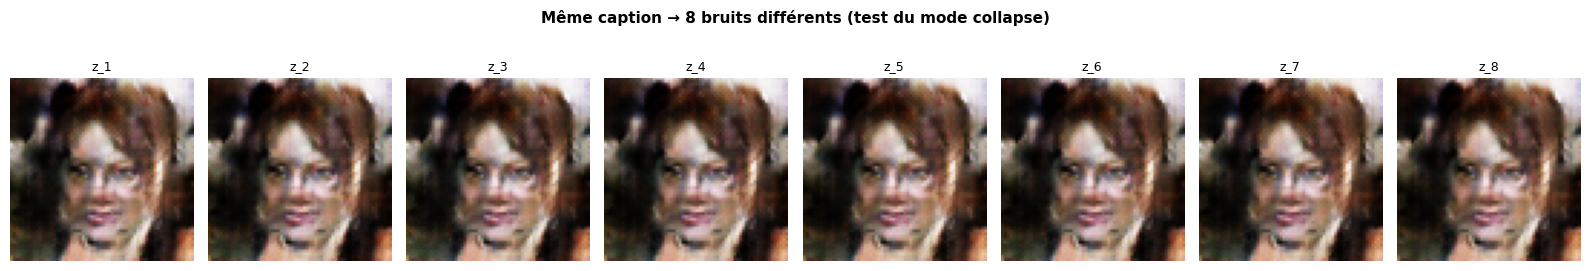

Generator(
  (text_proj): Sequential(
    (0): Linear(in_features=384, out_features=256, bias=True)
    (1): LeakyReLU(negative_slope=0.2, inplace=True)
  )
  (proj): Linear(in_features=356, out_features=8192, bias=True)
  (bn0): BatchNorm2d(512, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  (deconv1): ConvTranspose2d(512, 256, kernel_size=(4, 4), stride=(2, 2), padding=(1, 1), bias=False)
  (bn1): BatchNorm2d(256, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  (deconv2): ConvTranspose2d(256, 128, kernel_size=(4, 4), stride=(2, 2), padding=(1, 1), bias=False)
  (bn2): BatchNorm2d(128, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  (deconv3): ConvTranspose2d(128, 64, kernel_size=(4, 4), stride=(2, 2), padding=(1, 1), bias=False)
  (bn3): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  (deconv4): ConvTranspose2d(64, 3, kernel_size=(4, 4), stride=(2, 2), padding=(1, 1), bias=False)
)

In [17]:
# ── Diversité : même caption, bruit différent ─────────────────────────────────
# Vérifie l'absence de mode collapse (mentionné dans le papier)

test_caption = "The woman has high cheekbones. She has wavy hair which is brown in colour. She has big lips with arched eyebrows. The smiling, young woman has rosy cheeks and heavy makeup. She is wearing lipstick."
test_vec = sbert_eval.encode([test_caption], convert_to_tensor=True).to(DEVICE)
test_vec = test_vec.expand(8, -1)  # même caption, 8 fois

G.eval()
with torch.no_grad():
    z_diverse = torch.randn(8, CFG['z_dim'], device=DEVICE)  # bruits différents
    diverse_imgs = G(z_diverse, test_vec)
    diverse_imgs = (diverse_imgs + 1) / 2

fig, axes = plt.subplots(1, 8, figsize=(16, 3))
for i, ax in enumerate(axes):
    img = diverse_imgs[i].cpu().permute(1, 2, 0).numpy()
    img = np.clip(img, 0, 1)
    ax.imshow(img)
    ax.axis('off')
    ax.set_title(f'z_{i+1}', fontsize=9)

plt.suptitle('Même caption → 8 bruits différents (test du mode collapse)',
             fontsize=11, fontweight='bold')
plt.tight_layout()
plt.savefig('/kaggle/working/diversity_test.png', dpi=150, bbox_inches='tight')
plt.show()
G.train()

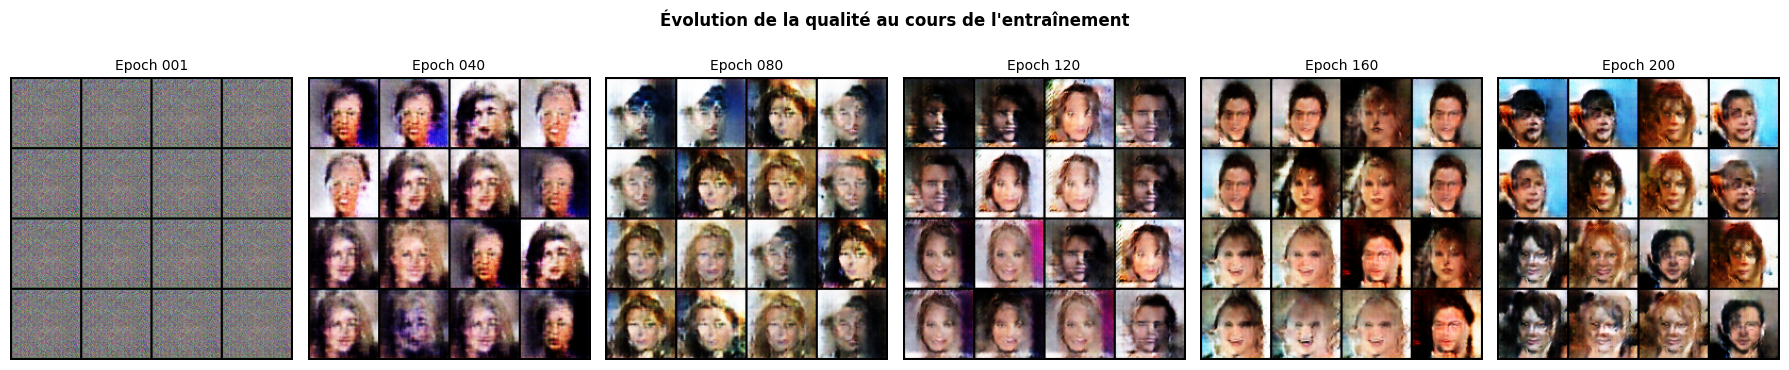

In [18]:
# ── Évolution de la génération au fil des epochs ──────────────────────────────
sample_files = sorted([
    f for f in os.listdir(CFG['samples_dir'])
    if f.endswith('.png')
])

if len(sample_files) > 0:
    # On prend max 6 snapshots régulièrement espacés
    indices = np.linspace(0, len(sample_files)-1, min(6, len(sample_files)), dtype=int)
    selected_files = [sample_files[i] for i in indices]

    fig, axes = plt.subplots(1, len(selected_files), figsize=(18, 4))
    if len(selected_files) == 1:
        axes = [axes]

    for ax, fname in zip(axes, selected_files):
        img = Image.open(os.path.join(CFG['samples_dir'], fname))
        ax.imshow(np.array(img))
        epoch_num = fname.split('_')[1]
        ax.set_title(f'Epoch {epoch_num}', fontsize=10)
        ax.axis('off')

    plt.suptitle('Évolution de la qualité au cours de l\'entraînement',
                 fontsize=12, fontweight='bold')
    plt.tight_layout()
    plt.savefig('/kaggle/working/training_progression.png', dpi=150, bbox_inches='tight')
    plt.show()

## 10. Tableau de synthèse des résultats

In [19]:
# ── Récapitulatif final ────────────────────────────────────────────────────────
print('=' * 65)
print('         SYNTHÈSE DES RÉSULTATS — Text2FaceGAN')
print('=' * 65)
print()
print('Architecture :')
print(f'  Encodeur texte  : Sentence-BERT (all-MiniLM-L6-v2, 384d)')
print(f'  Dim texte réduit: {CFG["text_reduced_dim"]}d (comme le papier)')
print(f'  Dim bruit z     : {CFG["z_dim"]}d')
print(f'  Résolution      : {CFG["image_size"]}×{CFG["image_size"]}px')
print(f'  Paramètres G    : {n_G:,}')
print(f'  Paramètres D    : {n_D:,}')
print()
print('Entraînement :')
print(f'  Epochs          : {CFG["epochs"]}')
print(f'  Batch size      : {CFG["batch_size"]}')
print(f'  lr G / D        : {CFG["lr_g"]} / {CFG["lr_d"]}')
print(f'  Label swap      : tous les {CFG["label_swap_every"]} batches')
print(f'  Train / Test    : {CFG["n_train"]} / {CFG["n_test"]} images')
print()
print('Résultats :')
print(f'  IS (notre)      : {is_mean:.2f} ± {is_std:.2f}')
print(f'  IS (papier)     : 1.40 ± 0.70')
print(f'  FID (notre)     : {fid_score:.2f}  (non reporté dans le papier)')
print()
print('Analyse critique :')
print('  • L\'IS est effectivement une mauvaise métrique pour les visages')
print('    (haute similarité inter-classes → IS peu discriminant)')
print('  • Le FID est plus adapté : mesure fidélité + diversité')
print('  • Sentence-BERT remplace avantageusement Skip-Thought :')
print('    plus léger, meilleurs embeddings sémantiques')
print('  • Le label swapping stabilise l\'entraînement (voir courbes)')
print('=' * 65)

         SYNTHÈSE DES RÉSULTATS — Text2FaceGAN

Architecture :
  Encodeur texte  : Sentence-BERT (all-MiniLM-L6-v2, 384d)
  Dim texte réduit: 256d (comme le papier)
  Dim bruit z     : 100d
  Résolution      : 64×64px
  Paramètres G    : 5,780,608
  Paramètres D    : 3,258,369

Entraînement :
  Epochs          : 200
  Batch size      : 64
  lr G / D        : 0.0002 / 0.0001
  Label swap      : tous les 3 batches
  Train / Test    : 7500 / 2500 images

Résultats :
  IS (notre)      : 1.65 ± 0.02
  IS (papier)     : 1.40 ± 0.70
  FID (notre)     : 138.99  (non reporté dans le papier)

Analyse critique :
  • L'IS est effectivement une mauvaise métrique pour les visages
    (haute similarité inter-classes → IS peu discriminant)
  • Le FID est plus adapté : mesure fidélité + diversité
  • Sentence-BERT remplace avantageusement Skip-Thought :
    plus léger, meilleurs embeddings sémantiques
  • Le label swapping stabilise l'entraînement (voir courbes)


In [20]:
# ── Sauvegarde finale du modèle ───────────────────────────────────────────────
torch.save({
    'G_state': G.state_dict(),
    'D_state': D.state_dict(),
    'history': history,
    'config' : CFG,
    'is_score': (is_mean, is_std),
    'fid_score': fid_score,
}, '/kaggle/working/text2facegan_final.pt')

print('Modèle final sauvegardé : /kaggle/working/text2facegan_final.pt')
print('\nFichiers générés :')
for f in os.listdir('/kaggle/working'):
    if f.endswith(('.pt', '.png', '.pkl')):
        size = os.path.getsize(f'/kaggle/working/{f}') / 1e6
        print(f'  {f:40s} ({size:.1f} Mo)')

Modèle final sauvegardé : /kaggle/working/text2facegan_final.pt

Fichiers générés :
  diversity_test.png                       (0.1 Mo)
  zero_shot_generation.png                 (0.2 Mo)
  training_progression.png                 (2.1 Mo)
  training_curves.png                      (0.1 Mo)
  ablation_label_swap.png                  (0.1 Mo)
  text2facegan_final.pt                    (36.2 Mo)
